# FTL099 - Inteligência Artificial Aplicada  
Aluno: Nycksandro Lima dos Santos  
Matrícula: 22351228  

# Trabalho 04 - Aprendizado Associativo

Descrição do problema

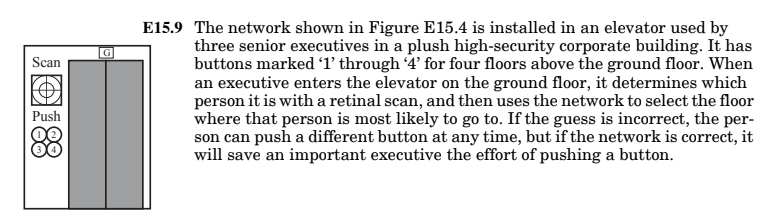

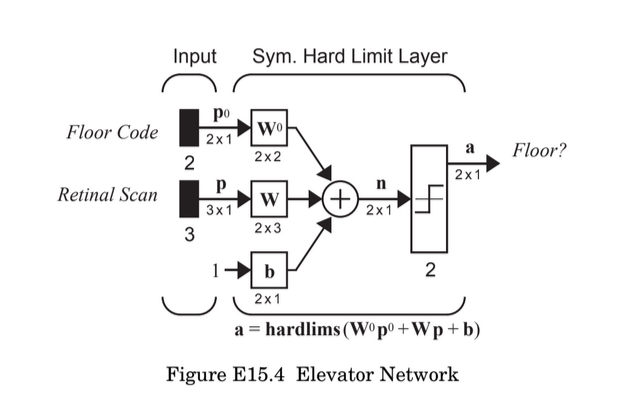

### **Importando bibliotecas**



In [ ]:
import numpy as np

## Questão 01

Use MATLAB to simulate the network for the following sequence of events:
1) President pushes ‘4’
2) Vice-President pushes ‘3’
3) Chairman pushes ‘1’
4) Vice-President pushes ‘3’
5) Chairman pushes ‘2’
6) President pushes ‘4’  

In other words, train the network on the following sequence:

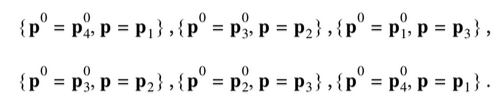

#### **Implementando hardlims**

In [ ]:
def hardlims(x): # Implementação da função hardlims
  return np.where(x >= 0, 1, -1) # Se os elementos forem maior que 0, vira 1, caso contrário vira -1

#### **Regra Outstar**

$$\mathbf{W}(k) = \mathbf{W}(k-1) + \alpha (\mathbf{a}(k) - \mathbf{W}(k-1))\mathbf{p}^T(k)$$

In [ ]:
def outstar(a, entrada, w_antigo, taxa_aprendizado):
    erro = a - (w_antigo @ entrada)
    w_novo = w_antigo + taxa_aprendizado * (erro @ entrada.T)
    return w_novo

### **Definição das variavéis principais e iniciais**

In [ ]:
andar_1 = np.array([[-1], # Primeiro andar
                    [-1]])

andar_2 = np.array([[1], # Segundo andar
                    [-1]])

andar_3 = np.array([[-1], # Terceiro andar
                    [1]])

andar_4 = np.array([[1], # Quarto andar
                    [1]])

nao_apertou = np.array([[0], # Não apertou
                       [0]])

retina_presidente = np.array([[1],
                             [0],
                             [0]])

retina_vice_p = np.array([[0],
                          [1],
                          [0]])

retina_chairman = np.array([[0],
                            [0],
                            [1]])

ordem_botoes_questao01 = [(retina_presidente, andar_4),
                          (retina_vice_p, andar_3),
                          (retina_chairman, andar_1),
                          (retina_vice_p, andar_3),
                          (retina_chairman, andar_2),
                          (retina_presidente, andar_4)]

#### **Variavéis iniciais definidas**

In [ ]:
taxa_aprendizado = 0.6 # Taxa de aprendizado definida

peso_retina_inicial = np.array([[0,0,0],
                        [0,0,0]])

peso_andar_inicial = np.array([[1,0],
                           [0,1]])

vies = np.array([[-0.5], # Viés inicial
                 [-0.5]])

In [ ]:
def treinamento(peso_inicial, ordem_botoes, taxa_aprendizado, vies):
  # Criamos uma cópia para não alterar a matriz de fora diretamente
  peso_atual = peso_inicial.copy()

  for i, botao in enumerate(ordem_botoes, start=1):
      retina, andar = botao

      if(andar is not None): # Verificando se foi apertado nenhum botão
        n = (peso_andar_inicial @ andar) + (peso_atual @ retina) + vies
        a = hardlims(n) # Calcuando a saída a

        peso_atual = outstar(a, retina, peso_atual, taxa_aprendizado) # Atualizando o peso usando outstar

        print(f"--- Passo {i} ---")
        print(f"Saída calculada (a):\n{a}")
        print(f"Matriz de Pesos Atualizada (W):\n{peso_atual}\n")

      else: # Caso não for, aqui o código do elevador será nulo (p0 = 0)
          n = (peso_atual @ retina) + vies
          a = hardlims(n)

          print(f"--- Passo {i} (Apenas Retina) ---")
          print(f"Saída calculada (a):\n{a}")
          print(f"Matriz de Pesos Atualizada:\n{peso_atual}\n")

  return peso_atual

In [ ]:
# Executa o treino
pesos_finais_questao01 = treinamento(peso_retina_inicial, ordem_botoes_questao01, taxa_aprendizado, vies)
print("==============================")
print(f"MATRIZ DE PESOS FINAL:\n{pesos_finais_questao01}")

--- Passo 1 ---
Saída calculada (a):
[[1]
 [1]]
Matriz de Pesos Atualizada (W):
[[0.6 0.  0. ]
 [0.6 0.  0. ]]

--- Passo 2 ---
Saída calculada (a):
[[-1]
 [ 1]]
Matriz de Pesos Atualizada (W):
[[ 0.6 -0.6  0. ]
 [ 0.6  0.6  0. ]]

--- Passo 3 ---
Saída calculada (a):
[[-1]
 [-1]]
Matriz de Pesos Atualizada (W):
[[ 0.6 -0.6 -0.6]
 [ 0.6  0.6 -0.6]]

--- Passo 4 ---
Saída calculada (a):
[[-1]
 [ 1]]
Matriz de Pesos Atualizada (W):
[[ 0.6  -0.84 -0.6 ]
 [ 0.6   0.84 -0.6 ]]

--- Passo 5 ---
Saída calculada (a):
[[-1]
 [-1]]
Matriz de Pesos Atualizada (W):
[[ 0.6  -0.84 -0.84]
 [ 0.6   0.84 -0.84]]

--- Passo 6 ---
Saída calculada (a):
[[1]
 [1]]
Matriz de Pesos Atualizada (W):
[[ 0.84 -0.84 -0.84]
 [ 0.84  0.84 -0.84]]

MATRIZ DE PESOS FINAL:
[[ 0.84 -0.84 -0.84]
 [ 0.84  0.84 -0.84]]


## Questão 02

What are the final weights?

MATRIZ DE PESOS FINAL:  

[[ 0.84 -0.84 -0.84]  
 [ 0.84  0.84 -0.84]]

## Questão 03

Now continue simulating the network on these events:
* President does not push a button,
* Vice-President does not push a button,
* Chairman does not push a button.

In [ ]:
ordem_botoes_questao03 = [(retina_presidente, andar_4), # 1 passo
                          (retina_vice_p, andar_3), # 2 passo
                          (retina_chairman, andar_1), # 3 passo
                          (retina_vice_p, andar_3), # 4 passo
                          (retina_chairman, andar_2), # 5 passo
                          (retina_presidente, andar_4), # 6 passo
                          (retina_presidente, None), # 7 passo
                          (retina_vice_p, None), # 8 passo
                          (retina_chairman, None)] # 9 passo

pesos_finais_questao03 = treinamento(peso_retina_inicial, ordem_botoes_questao03, taxa_aprendizado, vies)
print("==============================")
print(f"MATRIZ DE PESOS FINAL:\n{pesos_finais_questao03}")


--- Passo 1 ---
Saída calculada (a):
[[1]
 [1]]
Matriz de Pesos Atualizada (W):
[[0.6 0.  0. ]
 [0.6 0.  0. ]]

--- Passo 2 ---
Saída calculada (a):
[[-1]
 [ 1]]
Matriz de Pesos Atualizada (W):
[[ 0.6 -0.6  0. ]
 [ 0.6  0.6  0. ]]

--- Passo 3 ---
Saída calculada (a):
[[-1]
 [-1]]
Matriz de Pesos Atualizada (W):
[[ 0.6 -0.6 -0.6]
 [ 0.6  0.6 -0.6]]

--- Passo 4 ---
Saída calculada (a):
[[-1]
 [ 1]]
Matriz de Pesos Atualizada (W):
[[ 0.6  -0.84 -0.6 ]
 [ 0.6   0.84 -0.6 ]]

--- Passo 5 ---
Saída calculada (a):
[[-1]
 [-1]]
Matriz de Pesos Atualizada (W):
[[ 0.6  -0.84 -0.84]
 [ 0.6   0.84 -0.84]]

--- Passo 6 ---
Saída calculada (a):
[[1]
 [1]]
Matriz de Pesos Atualizada (W):
[[ 0.84 -0.84 -0.84]
 [ 0.84  0.84 -0.84]]

--- Passo 7 (Apenas Retina) ---
Saída calculada (a):
[[1]
 [1]]
Matriz de Pesos Atualizada:
[[ 0.84 -0.84 -0.84]
 [ 0.84  0.84 -0.84]]

--- Passo 8 (Apenas Retina) ---
Saída calculada (a):
[[-1]
 [ 1]]
Matriz de Pesos Atualizada:
[[ 0.84 -0.84 -0.84]
 [ 0.84  0.84 -0.84]]

## Questão 04

Which floors did the network take each executive to?

1) Passo:  Presidente foi ao 4 º andar
2) Passo: Vice-Presidente foi ao 3 º andar
3) Passo: Chairman foi ao 1 º  andar
4) Passo: Vice-Presidente foi ao 3 º andar
5) Passo: Chairman queria ir ao 2 º mas foi levado ao 1 º  andar
6) Passo: Presidente foi ao 4 º andar
7) Passo: Presidente foi ao 4 º andar apenas com a retina
8) Passo: Vice-Presidente foi ao 3 º apenas com a retina
9) Passo: Chairman foi ao 1 º andar apenas com a retina

## Questão 05

If the executives were to push the following buttons many times,
what would you expect the resulting weight matrix to look like?

* President pushes ‘3’,
* Vice-President pushes ‘2’,
* Chairman pushes ‘4’.

Ao apertar diversas vezes os mesmos andares, a matriz de peso irá convergir para o valor exato do andar desejado por cada executivo.

A matriz de pesos aos poucos irá se alterar até ficar assim:

Matriz de pesos:

[[-1, 1, 1]  
  [1, -1, 1]]  

In [ ]:
# Demonstrando a convergência

ordem_botoes_questao05 = [(retina_presidente, andar_3),
                          (retina_vice_p, andar_2),
                          (retina_chairman, andar_4),
                          (retina_presidente, andar_3),
                          (retina_vice_p, andar_2),
                          (retina_chairman, andar_4),
                          (retina_presidente, andar_3),
                          (retina_vice_p, andar_2),
                          (retina_chairman, andar_4),
                          (retina_presidente, andar_3),
                          (retina_vice_p, andar_2),
                          (retina_chairman, andar_4),
                          (retina_presidente, andar_3),
                          (retina_vice_p, andar_2),
                          (retina_chairman, andar_4),
                          (retina_presidente, andar_3),
                          (retina_vice_p, andar_2),
                          (retina_chairman, andar_4),
                          (retina_presidente, andar_3),
                          (retina_vice_p, andar_2),
                          (retina_chairman, andar_4)]

pesos_finais_questao05 = treinamento(peso_retina_inicial, ordem_botoes_questao05, taxa_aprendizado, vies)
print("==============================")
print(f"MATRIZ DE PESOS FINAL:\n{pesos_finais_questao05}")

--- Passo 1 ---
Saída calculada (a):
[[-1]
 [ 1]]
Matriz de Pesos Atualizada (W):
[[-0.6  0.   0. ]
 [ 0.6  0.   0. ]]

--- Passo 2 ---
Saída calculada (a):
[[ 1]
 [-1]]
Matriz de Pesos Atualizada (W):
[[-0.6  0.6  0. ]
 [ 0.6 -0.6  0. ]]

--- Passo 3 ---
Saída calculada (a):
[[1]
 [1]]
Matriz de Pesos Atualizada (W):
[[-0.6  0.6  0.6]
 [ 0.6 -0.6  0.6]]

--- Passo 4 ---
Saída calculada (a):
[[-1]
 [ 1]]
Matriz de Pesos Atualizada (W):
[[-0.84  0.6   0.6 ]
 [ 0.84 -0.6   0.6 ]]

--- Passo 5 ---
Saída calculada (a):
[[ 1]
 [-1]]
Matriz de Pesos Atualizada (W):
[[-0.84  0.84  0.6 ]
 [ 0.84 -0.84  0.6 ]]

--- Passo 6 ---
Saída calculada (a):
[[1]
 [1]]
Matriz de Pesos Atualizada (W):
[[-0.84  0.84  0.84]
 [ 0.84 -0.84  0.84]]

--- Passo 7 ---
Saída calculada (a):
[[-1]
 [ 1]]
Matriz de Pesos Atualizada (W):
[[-0.936  0.84   0.84 ]
 [ 0.936 -0.84   0.84 ]]

--- Passo 8 ---
Saída calculada (a):
[[ 1]
 [-1]]
Matriz de Pesos Atualizada (W):
[[-0.936  0.936  0.84 ]
 [ 0.936 -0.936  0.84 ]]

--